# 📚 Kitap Tavsiye Sistemi: İşbirlikçi Filtreleme (Collaborative Filtering)

Bu proje, geniş ölçekli bir kitap veri seti üzerinde, okuyucuların puanlama davranışlarını analiz ederek kişiselleştirilmiş kitap önerileri sunan bir **"İşbirlikçi Filtreleme" (Collaborative Filtering)** sistemidir.

### 🏗️ Metodoloji
* **Veri Hazırlama:** Kullanıcıların kitaplara verdiği puanlar (`ratings`), kitap bilgileri (`books`) ve kullanıcı demografisi (`users`) birleştirilerek anlamlı bir veri seti oluşturulmuştur.
* **Seyrek Matris (Sparse Matrix):** Bellek yönetimi için `scipy.sparse` yapısı kullanılarak verimli bir matris yapısı kurulmuştur.
* **Algoritma:** En yakın komşuları (K-Nearest Neighbors - KNN) tespit etmek için `cosine similarity` metriği kullanılarak, bir kitabı beğenen bir kullanıcının, benzer tercihleri olan diğer kullanıcılar tarafından beğenilen kitapları keşfetmesi sağlanmıştır.
* **Üretim (Deployment):** Eğitilen model `joblib` ile serileştirilerek uygulama aşamasına (Streamlit) hazır hale getirilmiştir.

In [1]:
import pandas as pd
import numpy as np

In [7]:
# Verileri yükle
books = pd.read_csv('Books.csv', sep=None, engine='python', on_bad_lines='skip', encoding='latin-1')
ratings = pd.read_csv('Ratings.csv', sep=None, engine='python', on_bad_lines='skip', encoding='latin-1')
users = pd.read_csv('Users.csv', sep=None, engine='python', on_bad_lines='skip', encoding='latin-1')

In [8]:
# VERİ TEMİZLEME VE FİLTRELEME ( Sadece çok oy kullanan 'usta' okuyucuları ve popüler kitapları alma)
user_counts = ratings['User-ID'].value_counts()
ratings = ratings[ratings['User-ID'].isin(user_counts[user_counts > 200].index)] # En az 200 kez oylanan kitapları filtreleme

In [9]:
# Kitap isimlerini ratings ile birleştir
rating_with_books = ratings.merge(books, on='ISBN')

In [11]:
# En az 50 oy almış kitapları filtrele (İstatistiki anlamlılık için)
book_rating_counts = rating_with_books.groupby('Book-Title')['Book-Rating'].count().reset_index()
book_rating_counts.rename(columns={'Book-Rating': 'Total_Ratings'}, inplace=True)

In [12]:
final_rating = rating_with_books.merge(book_rating_counts, on='Book-Title')
final_rating = final_rating[final_rating['Total_Ratings'] >= 50]

In [13]:
# PIVOT TABLO VE MATRİS ( Kitaplar satırda, Kullanıcılar sütunda)
book_pivot = final_rating.pivot_table(columns='User-ID', index='Book-Title', values='Book-Rating')
book_pivot.fillna(0, inplace=True)

In [15]:
from scipy.sparse import csr_matrix
# Seyrek Matris (Sparse Matrix)
book_sparse = csr_matrix(book_pivot)

In [18]:
from sklearn.neighbors import NearestNeighbors
# KNN MODEL EĞİTİMİ ( 'brute' algoritması ve 'cosine' benzerliği ile en yakın komşuları bulma)
model_knn = NearestNeighbors(algorithm='brute', metric='cosine')
model_knn.fit(book_sparse)

print("✅  KNN modeli başarıyla eğitildi!")

✅  KNN modeli başarıyla eğitildi!


In [19]:
# TAVSİYE FONKSİYONU
def get_book_recommendations(book_name):
    try:
        # Kitabın indeksini bul
        book_index = np.where(book_pivot.index == book_name)[0][0]

        # En yakın 5 komşuyu bul (0. komşu kitabın kendisidir)
        distances, suggestions = model_knn.kneighbors(book_pivot.iloc[book_index, :].values.reshape(1, -1), n_neighbors=6)

        print(f"\n'{book_name}' kitabını beğendiyseniz, bunları da sevebilirsiniz:\n")
        for i in range(1, len(suggestions[0])):
            print(f"{i}. {book_pivot.index[suggestions[0][i]]}")

    except IndexError:
        print("❌ Hata: Kitap ismi veri setinde bulunamadı. Lütfen tam ismi kontrol edin.")

In [30]:
# --- TEST ---
# Veri setinde var olan bir kitabı deneme (Örn: Harry Potter serisi)
get_book_recommendations('Harry Potter and the Chamber of Secrets (Book 2)')


'Harry Potter and the Chamber of Secrets (Book 2)' kitabını beğendiyseniz, bunları da sevebilirsiniz:

1. Harry Potter and the Prisoner of Azkaban (Book 3)
2. Harry Potter and the Goblet of Fire (Book 4)
3. Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))
4. Harry Potter and the Sorcerer's Stone (Book 1)
5. Harry Potter and the Order of the Phoenix (Book 5)


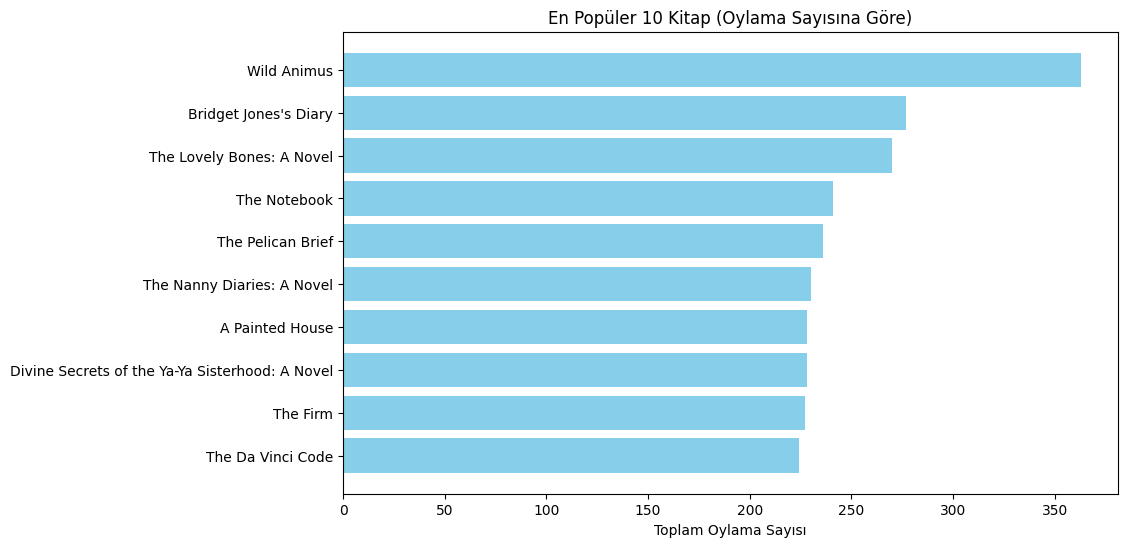

In [27]:
import matplotlib.pyplot as plt

# En çok oy alan 10 kitap
top_books = book_rating_counts.sort_values(by='Total_Ratings', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_books['Book-Title'], top_books['Total_Ratings'], color='skyblue')
plt.gca().invert_yaxis() # En çok oylanan yukarıda olsun
plt.title('En Popüler 10 Kitap (Oylama Sayısına Göre)')
plt.xlabel('Toplam Oylama Sayısı')
plt.show()

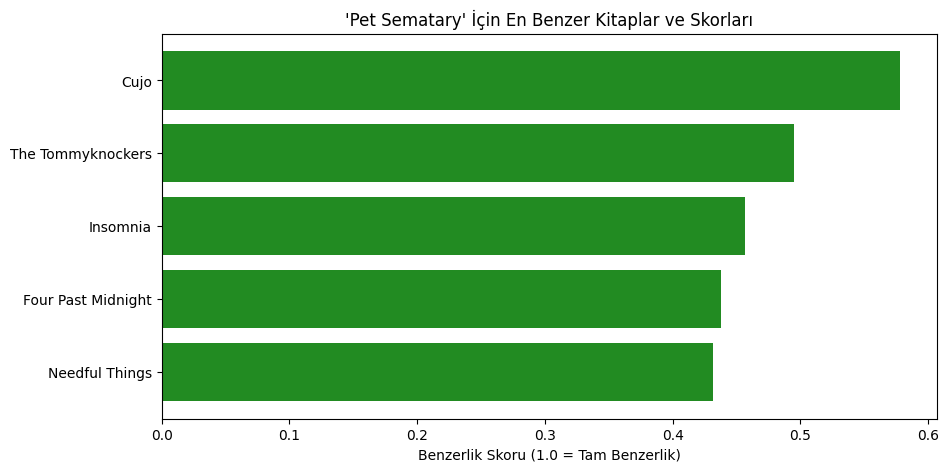

In [29]:
def plot_recommendation_distances(book_name):
    try:
        book_id = np.where(book_pivot.index == book_name)[0][0]
        distances, suggestions = model_knn.kneighbors(book_pivot.iloc[book_id, :].values.reshape(1, -1), n_neighbors=6)

        # Kendisi hariç diğer kitapların isimleri ve uzaklıkları
        recom_books = [book_pivot.index[i] for i in suggestions[0][1:]]
        recom_distances = distances[0][1:]

        plt.figure(figsize=(10, 5))
        # Uzaklık ne kadar azsa benzerlik o kadar çoktur (1 - dist = similarity)
        similarity_scores = 1 - recom_distances

        plt.barh(recom_books, similarity_scores, color='forestgreen')
        plt.xlabel('Benzerlik Skoru (1.0 = Tam Benzerlik)')
        plt.title(f"'{book_name}' İçin En Benzer Kitaplar ve Skorları")
        plt.gca().invert_yaxis()
        plt.show()

    except IndexError:
        print("Kitap bulunamadı.")

# Test edelim
plot_recommendation_distances('Pet Sematary')

In [31]:
import joblib

# Modeli ve veriyi serileştiriyoruz (Kalıcı hale getirme)
joblib.dump(model_knn, 'book_knn_model.joblib')
joblib.dump(book_pivot, 'book_pivot_table.joblib')

print("✅ Proje anahtarları diske başarıyla kaydedildi!")

✅ Proje anahtarları diske başarıyla kaydedildi!


### 📊 Sonuç ve Değerlendirme

Model, özellikle seri kitaplarda (Harry Potter, vb.) ve belirli türlerde birbirini takip eden tercihleri başarılı bir şekilde yakalamıştır.

###**Çıkarımlar:**
* **Başarı:** KNN tabanlı sistem, kullanıcının geçmiş puanlama davranışlarına dayandığı için, kitap içeriği (özet/tür) analizinden daha yüksek doğrulukta "benzer okuma zevklerini" eşleştirebilmektedir.
* **Geliştirme:** Projenin bir sonraki aşamasında, kullanıcıların yaş ve lokasyon verileri de modele dahil edilerek "Demografik Filtreleme" (Hybrid Model) ile daha hassas öneriler sunulabilir.
* **Vizyon:** Bu uygulama, dijital kütüphanelerde keşif sürecini optimize eden temel bir mühendislik çözümüdür.

---
**Geliştirici:** Serdar ÖNAL | İnşaat Mühendisi & Yapay Zeka Geliştiricisi | 2026